# T-Rex Dataset — quick start

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZhuoyangLiu2005/T-Rex/blob/main/dataset_quickstart/quickstart.ipynb)
&nbsp; [🤗 Dataset](https://huggingface.co/datasets/zekaiwang/trex_dataset) &nbsp;·&nbsp; [💻 Code](https://github.com/ZhuoyangLiu2005/T-Rex) &nbsp;·&nbsp; [🌐 Project page](https://tactile-rex.github.io/)

The **T-Rex Dataset** is a ~50-hour, tactile-reactive **bimanual** manipulation dataset (Dexmate Vega-1
with two Sharpa Wave dexterous hands; 22 motor primitives, 200+ objects), released as a
[LeRobotDataset v3.0](https://github.com/huggingface/lerobot). This single notebook lets you
**browse, filter, and inspect** the dataset **without downloading all ~1.4 TB** — it pulls only
`meta/` to browse, then only the files a single episode needs.

**Per frame (fps = 30):**

| feature | shape | notes |
|---|---|---|
| `observation.state` | (58,) | `[L_arm(7), L_hand(22), R_arm(7), R_hand(22)]` joint positions |
| `action` | (58,) | same layout, target positions |
| `observation.tactile_force` | (60,) | `(left, right) × (thumb..pinky) × (fx,fy,fz,mx,my,mz)` |
| `observation.images.{head_left,left_wrist,right_wrist}` | (360,640,3) video | RGB cameras |
| `observation.images.tactile_{left,right}_{raw,deform}_{thumb..pinky}` | (H,W,3) video | 20 grayscale tactile streams |

Per-episode metadata columns: `motor_primitive`, `object`, `target`, `caption`.

> The 20 tactile videos are **lossless grayscale** (the deform pixel value maps to estimated
> contact depth), so they may not render in the HuggingFace web viewer but decode correctly here.

## Setup

On Colab, run the install cell below first. If the dataset is gated/private, authenticate once with `from huggingface_hub import notebook_login; notebook_login()`.

In [ ]:
# On Colab (or any fresh environment), install dependencies first:
# !pip install -q huggingface_hub pandas pyarrow av numpy matplotlib

import glob
import json
from pathlib import Path
import numpy as np
import pandas as pd
import av
import matplotlib.pyplot as plt

In [ ]:
# ---- where the dataset lives ----
SOURCE = "zekaiwang/trex_dataset"  # a HuggingFace dataset repo id (downloads on demand)
# SOURCE = ...    # ...or a local LeRobotDataset directory (offline)

CACHE_DIR = Path.home() / ".cache" / "trex_quickstart"  # Hub downloads land here
MAX_GB = 10.0  # safety cap per episode fetch

# ---- schema constants ----
FPS = 30
FINGER_NAMES = ("thumb", "index", "middle", "ring", "pinky")
RGB_KEYS = [
    "observation.images.head_left",
    "observation.images.left_wrist",
    "observation.images.right_wrist",
]
F6_DIM = 6  # fx,fy,fz,mx,my,mz per finger; force layout = left[0:30], right[30:60]


def tactile_key(side, kind, finger):
    return f"observation.images.tactile_{side}_{kind}_{finger}"


# ---- access: a local dir OR a Hub repo, downloading only what's needed ----
def is_local(src):
    return Path(src).exists() and (Path(src) / "meta" / "info.json").exists()


def meta_root(src):
    """Local root with meta/ present. For a Hub repo, pulls only meta/ (a few MB)."""
    if is_local(src):
        return Path(src)
    from huggingface_hub import snapshot_download

    snapshot_download(
        repo_id=str(src), repo_type="dataset", allow_patterns=["meta/**"], local_dir=str(CACHE_DIR)
    )
    return CACHE_DIR


def load_episodes(root):
    files = sorted(glob.glob(str(Path(root) / "meta/episodes/**/*.parquet"), recursive=True))
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)


def fetch_episode(src, ep_row):
    """Make one episode's files available locally and return the dataset root.
    Local: no download. Hub: downloads only that episode's data parquet + the (shared)
    video files it points at, after a MAX_GB size check."""
    if is_local(src):
        return Path(src)
    from huggingface_hub import hf_hub_download, HfApi

    info = json.loads((CACHE_DIR / "meta" / "info.json").read_text())
    vkeys = [k for k, v in info["features"].items() if v.get("dtype") == "video"]
    files = {
        info["data_path"].format(
            chunk_index=int(ep_row["data/chunk_index"]), file_index=int(ep_row["data/file_index"])
        )
    }
    for k in vkeys:
        files.add(
            info["video_path"].format(
                video_key=k,
                chunk_index=int(ep_row[f"videos/{k}/chunk_index"]),
                file_index=int(ep_row[f"videos/{k}/file_index"]),
            )
        )
    files = sorted(files)
    sib = HfApi().repo_info(repo_id=str(src), repo_type="dataset", files_metadata=True).siblings
    sizes = {s.rfilename: (s.size or 0) for s in sib}
    gb = sum(sizes.get(f, 0) for f in files) / 1e9
    print(f"downloading {len(files)} files (~{gb:.2f} GB)")
    if gb > MAX_GB:
        raise RuntimeError(f"{gb:.1f} GB exceeds MAX_GB={MAX_GB}; raise MAX_GB to override")
    for f in files:
        hf_hub_download(repo_id=str(src), filename=f, repo_type="dataset", local_dir=str(CACHE_DIR))
    return CACHE_DIR


# ---- decode one frame of one video key for one episode (no lerobot/torch) ----
def decode_frame(root, key, ep_row, t, gray):
    """The episode's frame t for `key`, located via the from_timestamp pointer."""
    ci = int(ep_row[f"videos/{key}/chunk_index"])
    fi = int(ep_row[f"videos/{key}/file_index"])
    ts = float(ep_row[f"videos/{key}/from_timestamp"])
    path = Path(root) / "videos" / key / f"chunk-{ci:03d}" / f"file-{fi:03d}.mp4"
    target = int(round(ts * FPS)) + t
    want = ts + t / FPS
    fmt = "gray" if gray else "rgb24"

    def grab(seek):
        with av.open(str(path)) as c:
            st = c.streams.video[0]
            tb = st.time_base
            if seek:
                c.seek(max(int((want - 0.1) / tb), 0), stream=st, backward=True, any_frame=False)
            for fr in c.decode(video=0):
                if fr.pts is None:
                    return None
                if int(round(float(fr.pts * tb) * FPS)) >= target:
                    return fr.to_ndarray(format=fmt)
        return None

    fr = grab(True)
    if fr is None:
        fr = grab(False)
    if fr is None:
        raise RuntimeError(f"could not find frame {t} for {key}")
    return fr


# ---- per-episode numeric array (state / action / tactile_force) from the data parquet ----
def load_array(root, key, ep_row):
    ci = int(ep_row["data/chunk_index"])
    fi = int(ep_row["data/file_index"])
    path = Path(root) / "data" / f"chunk-{ci:03d}" / f"file-{fi:03d}.parquet"
    df = pd.read_parquet(path, columns=["episode_index", "frame_index", key])
    g = df[df["episode_index"] == int(ep_row["episode_index"])].sort_values("frame_index")
    return np.stack(g[key].to_numpy()).astype(np.float32)


print("LOCAL dir" if is_local(SOURCE) else f"Hub repo: {SOURCE}")

LOCAL dir


## 1. Browse & filter
Only `meta/` is downloaded here (a few MB). Filter by `motor_primitive`, `object`, `target`, or `caption`.

In [3]:
root = meta_root(SOURCE)
eps = load_episodes(root)
print(f"{len(eps)} episodes")
keep = ("episode_index", "length", "motor_primitive", "object", "target", "caption")
print("metadata columns:", [c for c in eps.columns if c in keep])
print()
print("top motor_primitives:")
print(eps["motor_primitive"].value_counts().head(10))
print()

# example: filter by primitive, and see which objects it covers
prim = "reach"
m = eps["motor_primitive"] == prim
print(
    f"{prim}: {int(m.sum())} episodes | objects:",
    eps.loc[m, "object"].value_counts().head(5).to_dict(),
)
display(eps.loc[m, ["episode_index", "motor_primitive", "object", "target", "caption"]].head())

# example: filter by caption text
cap = eps["caption"].str.contains("book", case=False, na=False)
print(f"captions mentioning 'book' -> {int(cap.sum())} episodes")

5464 episodes
metadata columns: ['episode_index', 'length', 'caption', 'motor_primitive', 'object', 'target']

top motor_primitives:
motor_primitive
grasp_and_lifting    741
reach                698
lift_and_place       620
wrap                 486
fold                 417
press                347
insert               201
peel                 198
wipe                 197
squeeze              173
Name: count, dtype: int64

reach: 698 episodes | objects: {'books': 10, 'phone': 10, 'bandage': 10, 'ethernet cable': 10, 'glasses': 10}


,episode_index,motor_primitive,object,target,caption
0,0,reach,books,NaN,Move your left hand toward the book.
1,1,reach,laptop,NaN,"Past the and block, move your right hand towar..."
2,2,reach,phone,NaN,"Past the controller, move your right hand towa..."
3,3,reach,bandage,NaN,"Past the orange cube, move your left hand towa..."
4,4,reach,ethernet cable,NaN,Move your right hand to the Ethernet cable on ...


captions mentioning 'book' -> 182 episodes


## 2. Inspect one episode
Pulls only that episode's files. Shows the 3 cameras + the 20 tactile streams at the
**peak-contact** frame, plus per-finger force over time. A real contact lights the *same
finger column* in the tactile grid and the force plot — your finger-order / alignment check.

In [4]:
EPISODE = 1234  # or pick one from a filter above
ep_row = eps[eps["episode_index"] == EPISODE].iloc[0]  # a row keeping all columns
length = int(ep_row["length"])
tgt = f" -> {ep_row['target']}" if isinstance(ep_row.get("target"), str) else ""
print(
    f"episode {EPISODE} | {length} frames | {ep_row['motor_primitive']} / {ep_row['object']}{tgt}"
)
print("caption:", ep_row["caption"])

droot = fetch_episode(SOURCE, ep_row)
f6 = load_array(droot, "observation.tactile_force", ep_row)  # (length, 60)

# per-finger force magnitude (length, 2 hands, 5 fingers) and the peak-contact frame
mag = np.zeros((length, 2, 5), np.float32)
for s, side in enumerate(("left", "right")):
    for fi in range(5):
        base = (0 if side == "left" else 30) + fi * F6_DIM
        mag[:, s, fi] = np.linalg.norm(f6[:, base : base + 3], axis=1)
t = int(mag.sum(axis=(1, 2)).argmax())
print("peak-contact frame:", t)

episode 1234 | 751 frames | pour / oil cruet
caption: Past the toy keyboard, use your right hand to tilt-pour the oil cruet towards the cup and set it back down on the table.
peak-contact frame: 205


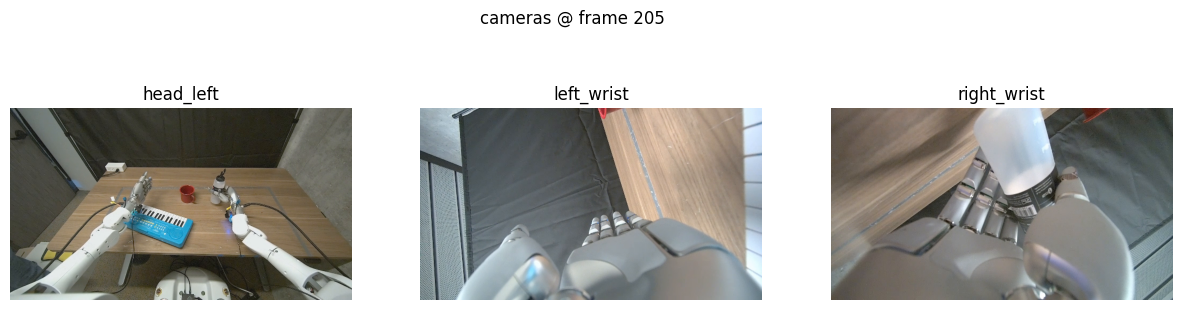

In [5]:
# cameras at the peak frame
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for j, k in enumerate(RGB_KEYS):
    ax[j].imshow(decode_frame(droot, k, ep_row, t, gray=False))
    ax[j].set_title(k.split(".")[-1])
    ax[j].axis("off")
fig.suptitle(f"cameras @ frame {t}")
plt.show()

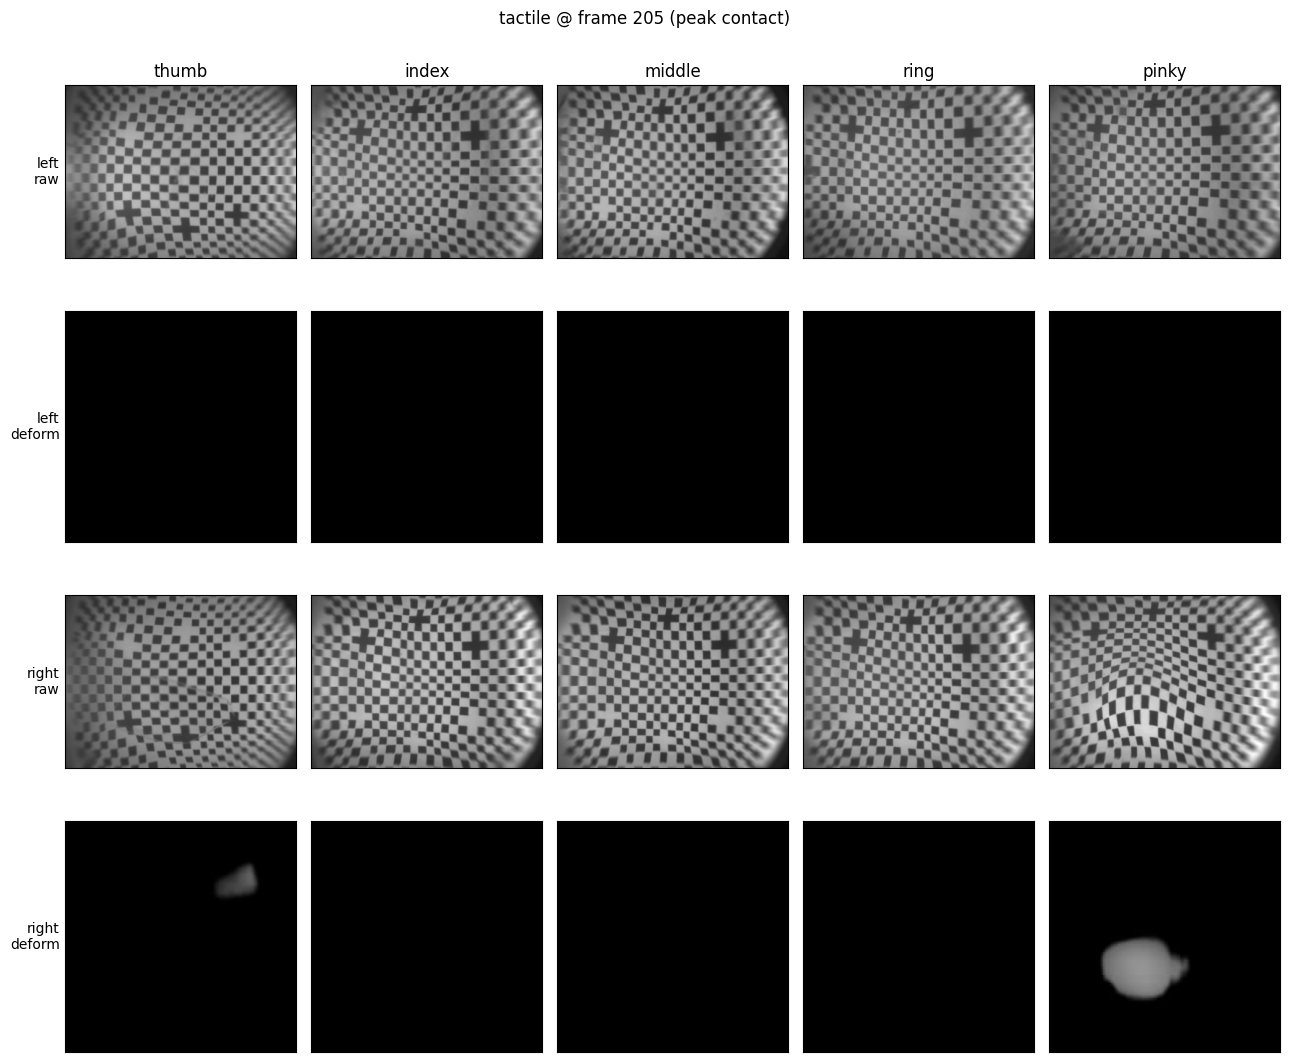

In [6]:
# tactile grid at the peak frame: rows = L raw / L deform / R raw / R deform, cols = thumb..pinky
rows = [("left", "raw"), ("left", "deform"), ("right", "raw"), ("right", "deform")]
fig, ax = plt.subplots(4, 5, figsize=(13, 11))
for r, (side, kind) in enumerate(rows):
    for c, fng in enumerate(FINGER_NAMES):
        a = ax[r, c]
        # grayscale; vmin/vmax pinned to full uint8 range so brightness is comparable across
        # the grid (imshow autoscales per-axes by default, distorting physical tactile values).
        a.imshow(
            decode_frame(droot, tactile_key(side, kind, fng), ep_row, t, gray=True),
            cmap="gray",
            vmin=0,
            vmax=255,
        )
        a.set_xticks([])
        a.set_yticks([])
        if r == 0:
            a.set_title(fng)
        if c == 0:
            a.set_ylabel(f"{side}\n{kind}", rotation=0, ha="right", va="center")
fig.suptitle(f"tactile @ frame {t} (peak contact)")
plt.tight_layout()
plt.show()

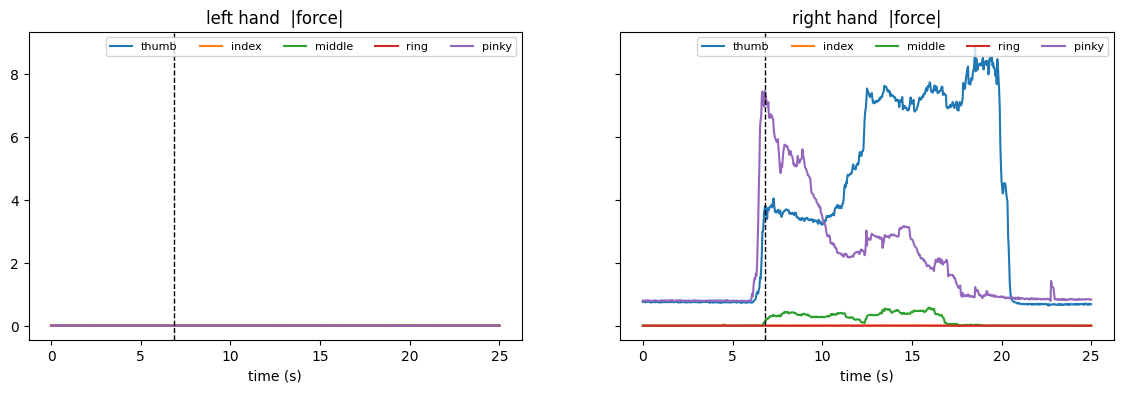

In [7]:
# per-finger force magnitude over time (the contacted finger should match the bright tactile column)
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for s, side in enumerate(("left", "right")):
    for fi, fng in enumerate(FINGER_NAMES):
        ax[s].plot(np.arange(length) / FPS, mag[:, s, fi], label=fng)
    ax[s].axvline(t / FPS, color="k", ls="--", lw=1)
    ax[s].set_title(f"{side} hand  |force|")
    ax[s].set_xlabel("time (s)")
    ax[s].legend(fontsize=8, ncol=5)
plt.show()

## 3. State / action trajectory (no robot needed)
The 58-D joint vectors are in the data parquet — here the left arm's 7 joints, state vs. target.

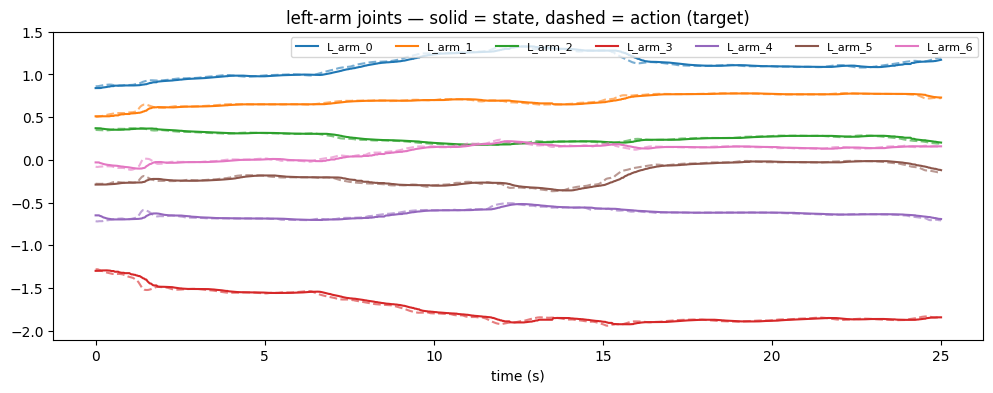

In [8]:
state = load_array(droot, "observation.state", ep_row)  # (length, 58)
action = load_array(droot, "action", ep_row)
tt = np.arange(length) / FPS
fig, ax = plt.subplots(figsize=(12, 4))
for j in range(7):  # left-arm dofs are indices 0:7
    (ln,) = ax.plot(tt, state[:, j], label=f"L_arm_{j}")
    ax.plot(tt, action[:, j], ls="--", color=ln.get_color(), alpha=0.6)
ax.set_title("left-arm joints — solid = state, dashed = action (target)")
ax.set_xlabel("time (s)")
ax.legend(ncol=7, fontsize=8)
plt.show()

## Load for training (full LeRobot loader)
For training you'll usually want the standard loader, which handles video decode + normalization
(it pulls in `torch` + `torchcodec`):

```python
from lerobot.datasets.lerobot_dataset import LeRobotDataset

keep = eps.loc[eps["motor_primitive"] == "reach", "episode_index"].tolist()
ds = LeRobotDataset("zekaiwang/trex_dataset", episodes=keep)   # downloads only those episodes
item = ds[0]   # decoded images + state/action + tactile_force, ready for a policy
```